<a href="https://colab.research.google.com/github/denverkim/WEBCRAWLING/blob/main/LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


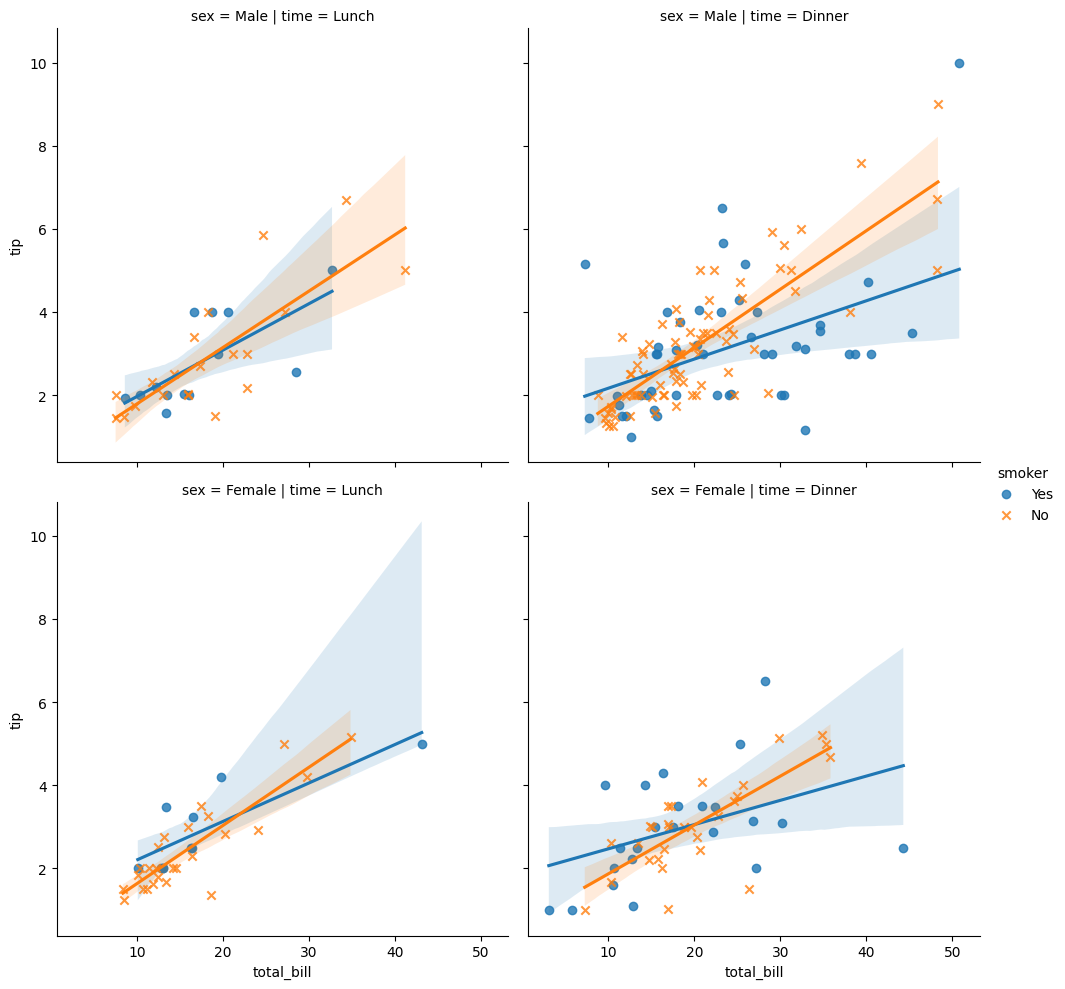

In [3]:
sns.lmplot(x='total_bill', y='tip', data=tips, hue='smoker', markers=['o', 'x'], col='time', row='sex')
plt.show()

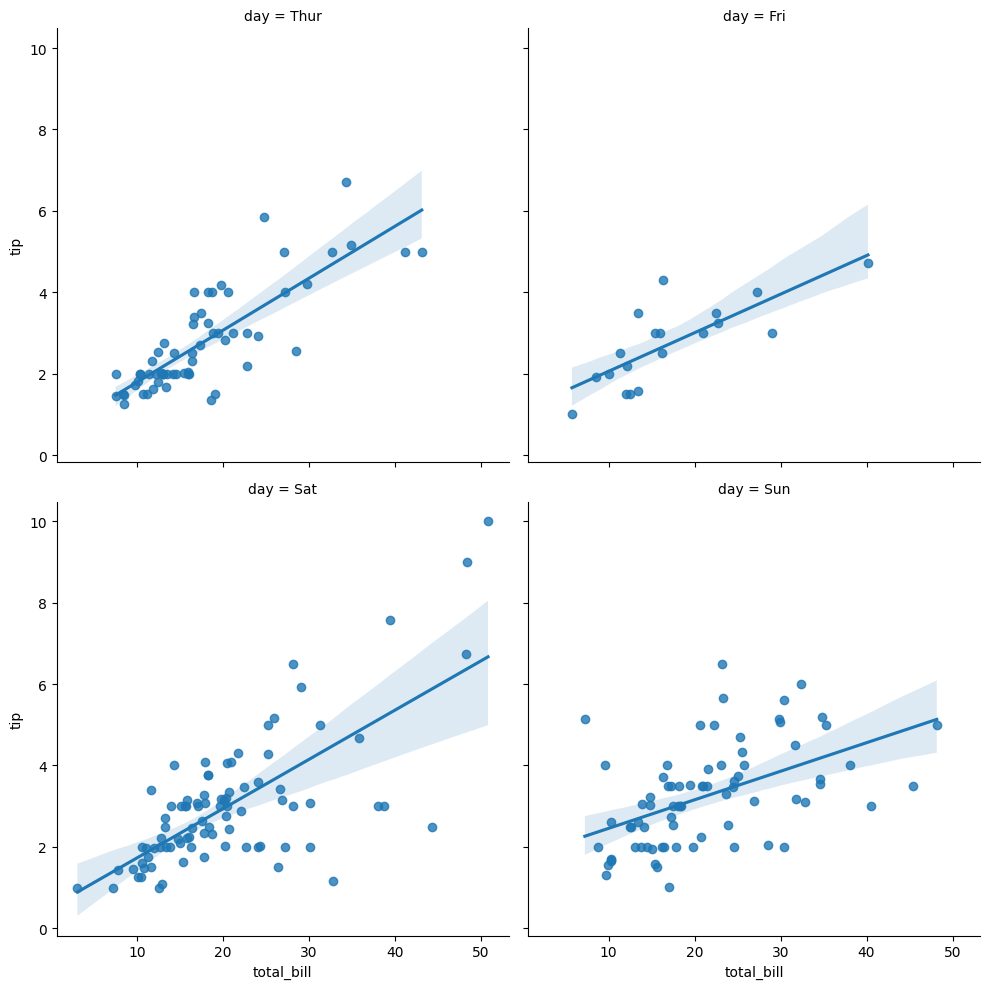

In [4]:
sns.lmplot(x='total_bill', y='tip', data=tips, col='day', col_wrap=2)
plt.show()

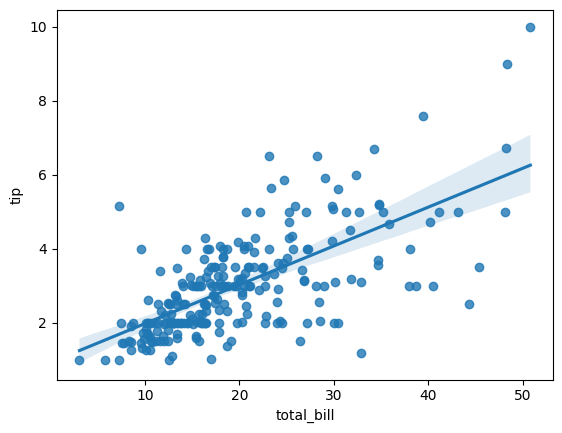

In [5]:
sns.regplot(x='total_bill', y='tip', data=tips)
plt.show()

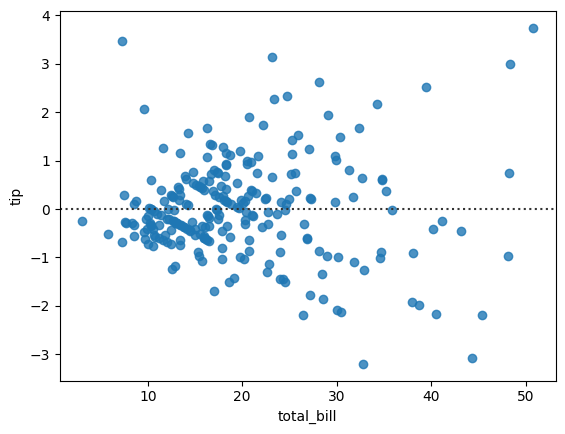

In [6]:
sns.residplot(x='total_bill', y='tip', data=tips)
plt.show()

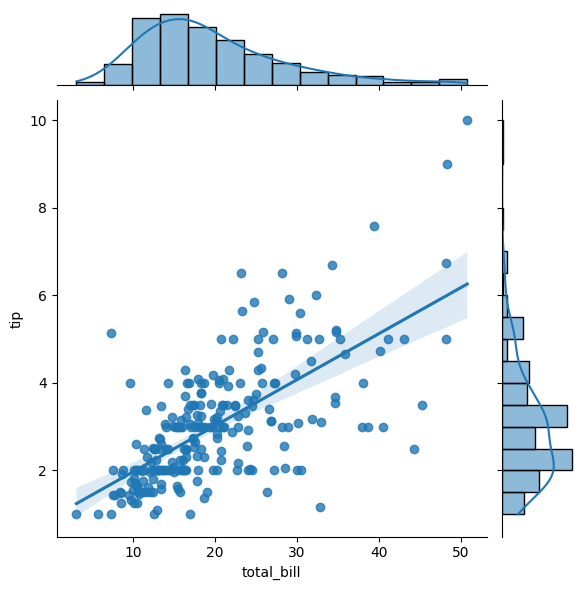

In [7]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')
plt.show()

/tmp/ipykernel_5477/243933064.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])


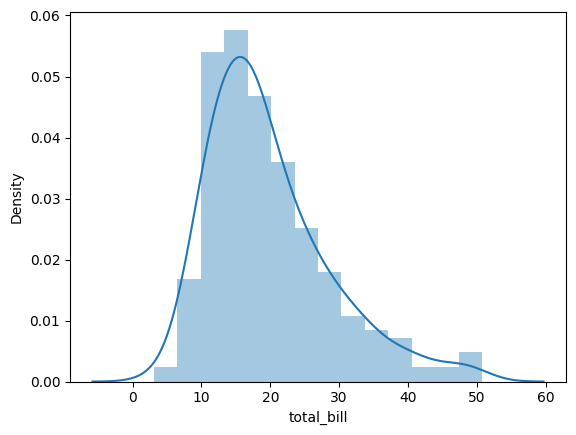

In [8]:
sns.distplot(tips['total_bill'])
plt.show()

<Axes: >

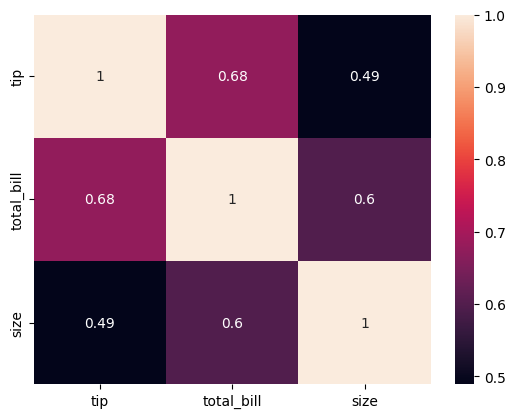

In [9]:
sns.heatmap(tips[['tip', 'total_bill', 'size']].corr(), annot=True)

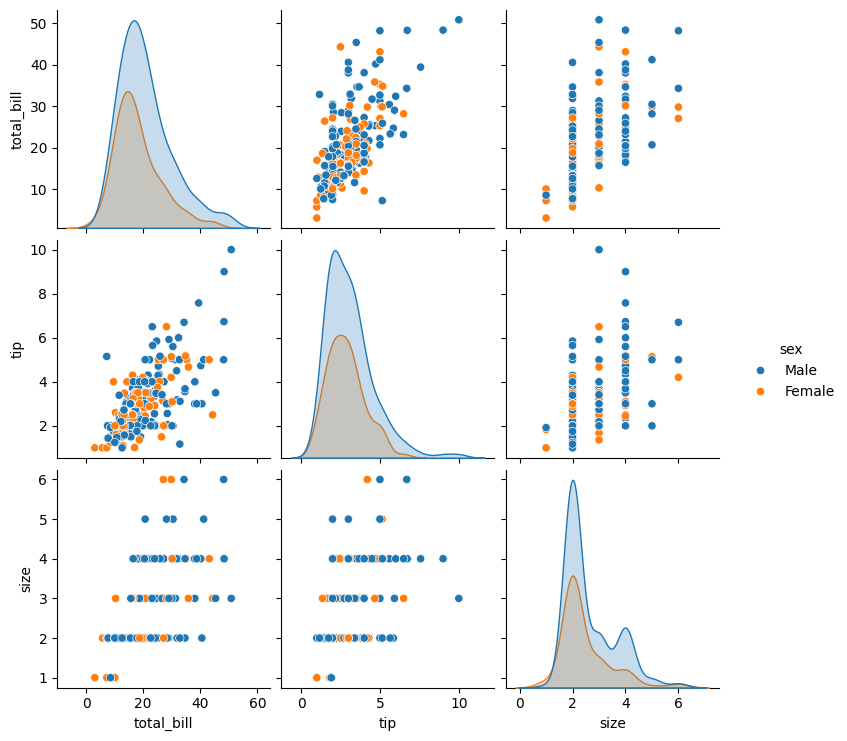

In [10]:
sns.pairplot(data=tips, hue='sex')
plt.show()

In [7]:
import requests
from bs4 import BeautifulSoup

page = requests.get('https://apis.data.go.kr/1240000/bpp_openapi/getPriceInfo?serviceKey=aSkTEXbtl4XRymqEwiFSQEGeMPo3tK%2B7pQ8nLVw4qlxJOhgTYTvPvODJ1nshAM2iu6R9EvCvAh5OvCu01y2Myg%3D%3D&pageNo=1&numOfRows=10&itemCode=A01101&startDate=20250101&endDate=20250101')
soup = BeautifulSoup(page.content, 'html.parser')
print(soup.prettify())

<?xml version="1.0" encoding="UTF-8" standalone="yes" ?>
<response>
 <body>
  <ic>
   A01101
  </ic>
  <in>
   쌀
  </in>
  <items>
   <item>
    <pi>
     999303916
    </pi>
    <pn>
     태국쌀 10kg 베트남쌀 안남미 수입쌀 THAI LONG GRAIN WHITE RICE
    </pn>
    <sp>
     28800
    </sp>
    <dp>
     28800
    </dp>
    <bp>
     0
    </bp>
    <sd>
     2025-01-01
    </sd>
   </item>
   <item>
    <pi>
     998315236
    </pi>
    <pn>
     당진 해나루 삼광쌀 특등급 20kg 23년산
    </pn>
    <sp>
     54300
    </sp>
    <dp>
     54300
    </dp>
    <bp>
     0
    </bp>
    <sd>
     2025-01-01
    </sd>
   </item>
   <item>
    <pi>
     998200272
    </pi>
    <pn>
     프레시데이 국내산쌀로 만든 누룽지 쌀과자 튀룽 구운오징어맛 77g
    </pn>
    <sp>
     2760
    </sp>
    <dp>
     2760
    </dp>
    <bp>
     0
    </bp>
    <sd>
     2025-01-01
    </sd>
   </item>
   <item>
    <pi>
     99810817
    </pi>
    <pn>
     바이오마켓_새청무 여주농산 쌀  2개  20kg
    </pn>
    <sp>
     183680
    </sp>
    <dp>
     183680
    </dp>
    

/tmp/ipykernel_12851/582370118.py:5: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(page.content, 'html.parser')


In [8]:
pi_list = [pi.text for pi in soup.find_all('pi')]
pn_list = [pn.text for pn in soup.find_all('pn')]
sp_list = [sp.text for sp in soup.find_all('sp')]
sd_list = [sd.text for sd in soup.find_all('sd')]

In [9]:
len(pi_list), len(pn_list), len(sp_list), len(sd_list)

(10, 10, 10, 10)

In [10]:
import pandas as pd

df = pd.DataFrame({'pi': pi_list,
              'pn': pn_list,
              'sp': sp_list,
              'sd': sd_list})
df

,pi,pn,sp,sd
0,999303916,태국쌀 10kg 베트남쌀 안남미 수입쌀 THAI LONG GRAIN WHITE RICE,28800,2025-01-01
1,998315236,당진 해나루 삼광쌀 특등급 20kg 23년산,54300,2025-01-01
2,998200272,프레시데이 국내산쌀로 만든 누룽지 쌀과자 튀룽 구운오징어맛 77g,2760,2025-01-01
3,99810817,바이오마켓_새청무 여주농산 쌀 2개 20kg,183680,2025-01-01
4,995821231,신동진 햅쌀 맛있는쌀 당일도정 해남쌀 상등급 쌀 백미 20kg,69800,2025-01-01
5,990652297,24년 햅쌀 20kg 수향미 경기미 고시히카리 신동진 영호진미 백진주 대왕님표 여...,108340,2025-01-01
6,984906882,GAP 철원 오대쌀 5KG(포),24900,2025-01-01
7,984129623,GAP 철원 오대쌀 2KG(봉),10900,2025-01-01
8,983025399,GAP 철원 오대쌀 10KG(포),29900,2025-01-01
9,974852705,당일도정 보령농협 빛고운황진쌀 4kg 24년산 햅쌀 GAP 농협쌀,45400,2025-01-01


In [13]:
df.dtypes

,0
pi,object
pn,object
sp,object
sd,object


In [14]:
df.sp = df.sp.astype('int')

In [27]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,935 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and dire

In [1]:
# 폰트 패쓰 확인
from matplotlib import font_manager
font_manager.findSystemFonts()

['/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
 '/usr/share/fonts/truetype/humor-sans/Humor-Sans.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareB.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumSquareR.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationMono-BoldItalic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Italic.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-Bold.ttf',
 '/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf',
 '/usr/share/fonts/truetype/liberation/LiberationSansNarrow-BoldItalic.ttf',
 '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
 '/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf',
 '/usr/shar

In [5]:
# 폰트 설정
import matplotlib.pyplot as plt
font_name = font_manager.FontProperties(fname="/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf").get_name()
plt.rc('font', family=font_name)

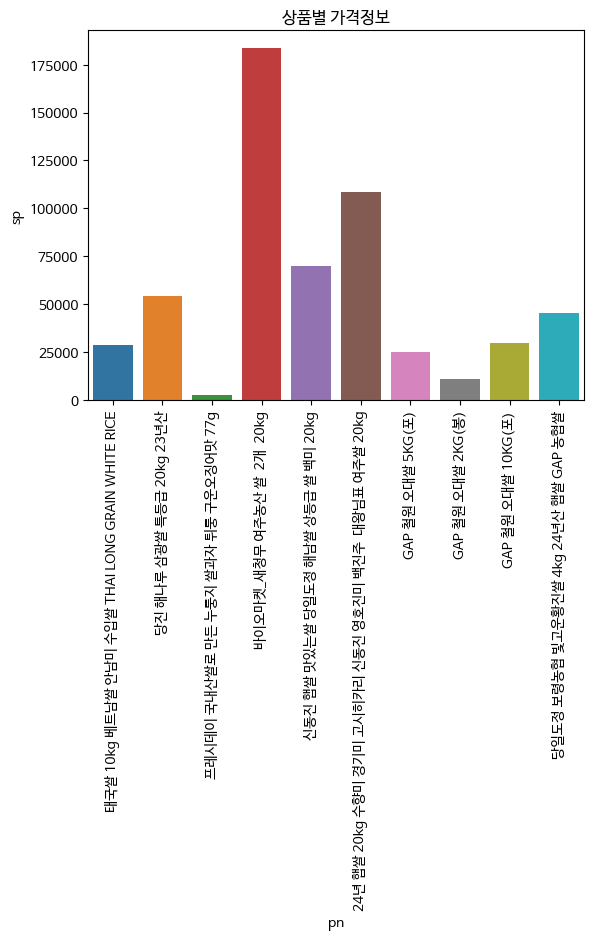

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='pn', y='sp', hue='pn')
plt.xticks(rotation=90)
plt.title('상품별 가격정보')
plt.show()